In [1]:
from ddi_kt_2024.utils import (
    load_pkl,
    get_labels
)
test_candidates = load_pkl("cache/pkl/v2/notprocessed.candidates.test.pkl")
full_labels = get_labels(test_candidates)
with open('cache/filtered_ddi/test_filtered_index.txt', 'r') as f:
    lines = f.read().split('\n')[:-1]
    filtered_lst_index_test = [int(x.strip()) for x in lines]

2025-05-18 02:50:56,236 - DEBUG - Popen(['git', 'version'], cwd=/teamspace/studios/this_studio/DDI-Multimodals-Fusion, stdin=None, shell=False, universal_newlines=False)
2025-05-18 02:50:56,250 - DEBUG - Popen(['git', 'version'], cwd=/teamspace/studios/this_studio/DDI-Multimodals-Fusion, stdin=None, shell=False, universal_newlines=False)
2025-05-18 02:50:56,302 - DEBUG - Trying paths: ['/teamspace/studios/this_studio/.docker/config.json', '/teamspace/studios/this_studio/.dockercfg']
2025-05-18 02:50:56,305 - DEBUG - Found file at path: /teamspace/studios/this_studio/.docker/config.json
2025-05-18 02:50:56,306 - DEBUG - Couldn't find auth-related section ; attempting to interpret as auth-only file
2025-05-18 02:50:56,308 - DEBUG - Auth data for auths is absent. Client might be using a credentials store instead.
2025-05-18 02:50:56,309 - DEBUG - Auth data for aliases is absent. Client might be using a credentials store instead.


In [3]:
filtered_labels = [full_labels[i] for i in filtered_lst_index_test]

In [7]:
pred = load_pkl('/teamspace/studios/this_studio/DDI-Multimodals-Fusion/pred_logit_epoch31val_micro_f10.8375893769152196.pkl')

In [10]:
pred[10]

array([30.220587 , -3.9370465, -6.2398934, -6.1367507, -4.415363 ],
      dtype=float32)

2025-05-18 02:56:41,463 - DEBUG - matplotlib data path: /home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/matplotlib/mpl-data
2025-05-18 02:56:41,477 - DEBUG - CONFIGDIR=/teamspace/studios/this_studio/.config/matplotlib
2025-05-18 02:56:41,521 - DEBUG - interactive is False
2025-05-18 02:56:41,522 - DEBUG - platform is linux
2025-05-18 02:56:41,634 - DEBUG - CACHEDIR=/home/zeus/.cache/matplotlib
2025-05-18 02:56:41,635 - DEBUG - font search path [PosixPath('/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf'), PosixPath('/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/afm'), PosixPath('/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/pdfcorefonts')]
2025-05-18 02:56:42,126 - INFO - generated new fontManager
2025-05-18 02:56:42,515 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-05-18 02:56:42,517

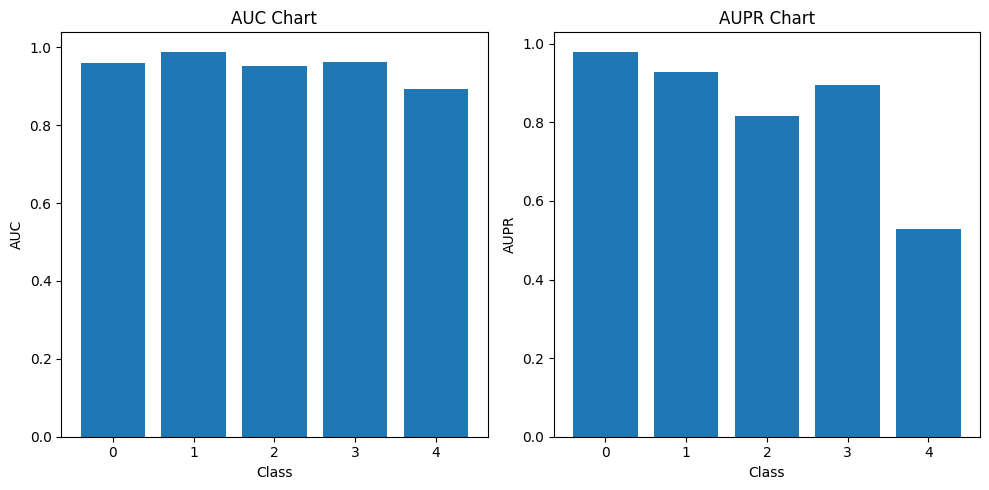

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

# Assuming pred shape is (3028, 5) and label is an array of len 3028
pred = pred  # your prediction array
label = filtered_labels  # your label array

# Apply softmax to pred
pred_softmax = np.exp(pred) / np.sum(np.exp(pred), axis=1, keepdims=True)

# One-hot encode the labels
label_onehot = np.zeros((len(label), 5))
label_onehot[np.arange(len(label)), label] = 1

# Calculate AUC for each class
auc_values = []
for i in range(5):
    auc_values.append(roc_auc_score(label_onehot[:, i], pred_softmax[:, i]))

# Calculate AUPR for each class
aupr_values = []
for i in range(5):
    precision, recall, _ = precision_recall_curve(label_onehot[:, i], pred_softmax[:, i])
    aupr_values.append(auc(recall, precision))

# Create AUC and AUPR charts
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.bar(range(5), auc_values)
plt.xlabel('Class')
plt.ylabel('AUC')
plt.title('AUC Chart')

plt.subplot(1, 2, 2)
plt.bar(range(5), aupr_values)
plt.xlabel('Class')
plt.ylabel('AUPR')
plt.title('AUPR Chart')

plt.tight_layout()
plt.show()

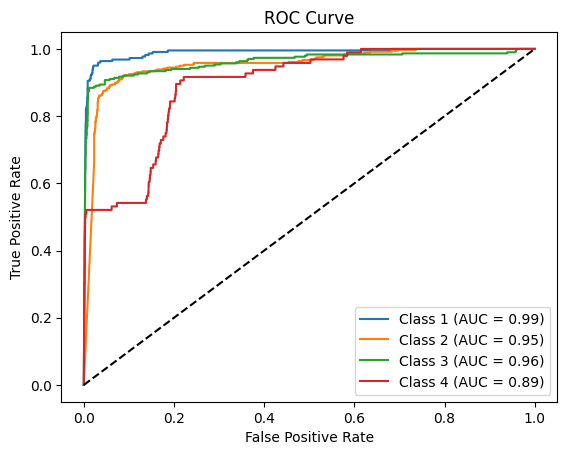

In [18]:
from sklearn.metrics import roc_curve, auc
for i in range(1,5):
    fpr, tpr, _ = roc_curve(label_onehot[:, i], pred_softmax[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

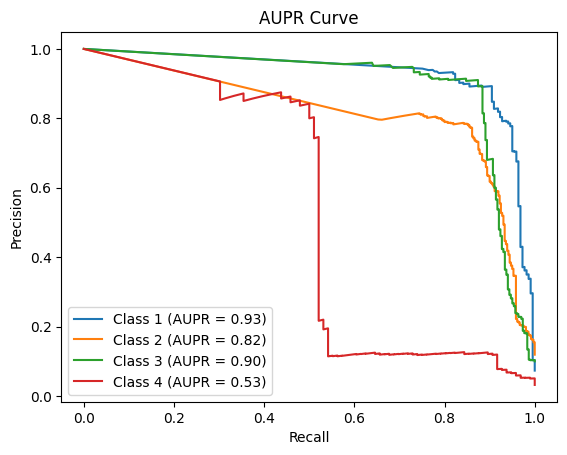

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# Assuming pred shape is (3028, 5) and label is an array of len 3028
pred = pred  # your prediction array
label = filtered_labels  # your label array

# One-hot encode the labels
label_onehot = np.zeros((len(label), 5))
label_onehot[np.arange(len(label)), label] = 1

# Plot AUPR Curve for each class
for i in range(1,5):
    precision, recall, _ = precision_recall_curve(label_onehot[:, i], pred_softmax[:, i])
    aupr = auc(recall, precision)
    plt.plot(recall, precision, label=f'Class {i} (AUPR = {aupr:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('AUPR Curve')
plt.legend()
plt.savefig('aupr_curve.png', dpi=300) 
plt.show()